### Chatbot w Multiple Tool Integration Using LangGraph

##### Aim: Create a chatbot with tool capabilities from asixiv, tavily search wikipedia and some functions

the tools we want to add- arxiv(researchpaper) & wikipedia(content), ADD FUNCTION and MULTPLY FUNCTION

there are many langgraph tools available on the official langchain github page

In [2]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [ ]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [6]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [12]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [14]:
result=wiki.invoke("What is a machine")
print(result)

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi


In [15]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [21]:
#Tavily Search Tool in the docs
from langchain_community.tools.tavily_search import TavilySearchResults

tavily=TavilySearchResults()

In [22]:
tavily.invoke("Provide me the recent AI news for january 3rd 2026")

[{'title': 'Weekly AI News January 3 2026: The Pulse And The Pattern',
  'url': 'https://www.youtube.com/watch?v=ox4m9J-zBHA',
  'content': "Read the full article: https://binaryverseai.com/ai-news-january-3-2026-15-weekly-updates-roundup/ This week in AI didn't feel like a tidy",
  'score': 0.85624856},
 {'title': 'The Artificial Intelligence (AI) Winner Hiding in Plain Sight for 2026',
  'url': 'https://www.fool.com/investing/2026/02/01/the-artificial-intelligence-ai-winner-hiding-in-pl/',
  'content': "Bloomberg points out that Marvell's relationships with Amazon and Microsoft for its custom AI processors would enable it to capture a nice chunk of this lucrative opportunity. And Marvell could do better than that. That's because Marvell doesn't just make custom AI processors; it also makes networking and storage components that go into data centers. [...] The Motley Fool\nThe Motley Fool\n\nThis semiconductor company is growing at an incredible pace due to AI, but the stock hasn't be

In [23]:
# Combine all the tools in the list
tools=[arxiv,wiki,tavily]

In [24]:
# Initialize my LLM model
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")
llm_w_tools=llm.bind_tools(tools)


In [25]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_w_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6r1qr9gvq', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 553, 'total_tokens': 573, 'completion_time': 0.030786581, 'prompt_time': 0.045550916, 'queue_time': 0.054212003, 'total_time': 0.076337497}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c8ff4823-29f8-4740-be22-aadd8c00dc30-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': '6r1qr9gvq', 'type': 'tool_call'}], usage_metadata={'input_tokens': 553, 'output_tokens': 20, 'total_tokens': 573})

In [26]:
llm_w_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'w4aksv27n',
  'type': 'tool_call'}]

### Construct Entire Chatbot with LangGraph

In [28]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

state["messages"] returns:

A list of messages (the conversation history) from the graph's state
These are message objects like HumanMessage, AIMessage, etc.
Example: [HumanMessage(content="What is the recent AI news?")]
llm_w_tools.invoke(state["messages"]) invokes:

Your LLM model (ChatGroq) with those messages
The LLM reads the message history and decides:
Whether to call a tool (arxiv, wiki, or tavily)
What to respond with
Returns an AIMessage that contains:
The LLM's text response
tool_calls attribute (if the LLM decided to use a tool)

In [32]:
from IPython.display import Image,display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_w_tools.invoke(state["messages"])]}

#Build Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools)) #giving all tools. tools=[arxiv, tavily, wiki]


builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools",END)
graph=builder.compile()


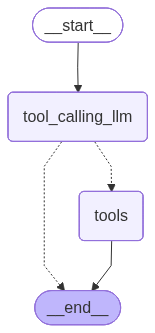

In [34]:
#view

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
messages=graph.invoke({"messages":HumanMessage(content="What is attention is all you need")})
for n in messages['messages']:
    n.pretty_print()

================================ Human Message =================================

What is attention is all you need
================================== Ai Message ==================================
Tool Calls:
  arxiv (7m09n8gvf)
 Call ID: 7m09n8gvf
  Args:
    query: Attention is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [37]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the most recent AI news for January 1st 2026")})
for n in messages['messages']:
    n.pretty_print()

================================ Human Message =================================

Provide me the most recent AI news for January 1st 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (qa9t2yemp)
 Call ID: qa9t2yemp
  Args:
    query: AI news January 1st 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News Roundup: January 01 – January 13, 2026 - Prompt Injection", "url": "https://www.promptinjection.net/p/ai-llm-news-roundup-january-01-january-13-2026", "content": "xAI posts $1.46B quarterly loss as spending accelerates\n\nReuters reported internal documents showing xAI’s quarterly net loss widened to $1.46 billion as it spent heavily to build its AI business. The report described significant cash burn relative to revenue, reflecting the high costs of training and serving large models. The numbers were presented as evidence 

In [38]:
messages=graph.invoke({"messages":HumanMessage(content="What is Machine Learning")})
for n in messages['messages']:
    n.pretty_print()

================================ Human Message =================================

What is Machine Learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (c3r75w9hc)
 Call ID: c3r75w9hc
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
